# Estimate agricultural land fraction using CORINE land cover (exposure)

This short how-to guides you through the steps to create a timeseries of the agricultural land fraction using CORINE land cover data and save it as a csv file. The final csv file can be used as, e.g., exposure data for the drought risk estimation. 

## Manual download of CORINE land cover data via web interface

We download the CORINE land cover manually using the Copernicus Land viewer available through: [https://land.copernicus.eu/en/products/corine-land-cover](https://land.copernicus.eu/en/products/corine-land-cover)

In the viewer, we select the CORINE land cover data for all years available, i.e., 1990, 2000, 2006, 2012, and 2018. To reduce the amount of data that we download, we further reduce the spatial extent to the administrative region that we're looking at, e.g., the NUTS-2 region "Central Greece" (EL64). The image below shows the selection process. 

![Image](../img/corine_download_viewer.png "CORINE land cover data selected for this example: NUTS region 2 'EL64' (Central Greece), and CORINE land cover from 1990, 2000, 2006, 2012, and 2018.")

Once selected, we add click on the download symbol for each dataset (year), and process to the cart.  To facilitate the use of this data for our purposes, we select the "raster" format and download the data on the EPSG: 4326 projection; a projection typically used for climate projections. The image below shows the selection of format and projection. 
![Image](../img/corine_download_cart.png "CORINE land cover download.")
 

Once downloaded, we move this data into the following subdirectory: 

In [21]:
"./data/corine_landcover"

'./data/corine_landcover'

## Read and visualize CORINE land cover data

In [42]:
import zipfile
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path
import rioxarray as rxr
import os
import re
data_dir = Path("./data/corine_landcover")
print(os.getcwd())

/etc/ecmwf/nfs/dh2_home_a/nejk/code/drought_exposure


In [38]:
# List all tif-files in data_dir
tif_files = list(data_dir.glob("*/*/*.tif"))
print(f"Found {len(tif_files)} tif files.")
for f in tif_files:
    print(f)

Found 5 tif files.
data/corine_landcover/U2018_CLC2012_V2020_20u1_raster100m/U2018_CLC2012_V2020_20u1_raster100m/U2018_CLC2012_V2020_20u1_raster100m.tif
data/corine_landcover/U2000_CLC1990_V2020_20u1/U2000_CLC1990_V2020_20u1/U2000_CLC1990_V2020_20u1.tif
data/corine_landcover/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif
data/corine_landcover/U2012_CLC2006_V2020_20u1/U2012_CLC2006_V2020_20u1/U2012_CLC2006_V2020_20u1.tif
data/corine_landcover/U2006_CLC2000_V2020_20u1/U2006_CLC2000_V2020_20u1/U2006_CLC2000_V2020_20u1.tif


In [48]:
# Read all tif files into a single xarray dataset
datasets = []
years = []

for tif_file in tif_files:
    # Read using rioxarray
    ds = rxr.open_rasterio(tif_file)
    
    # Extract year from filename - look for pattern like CLC1990, CLC2000, etc.
    year_match = re.search(r'CLC(\d{4})', tif_file.name)
    if year_match:
        year = int(year_match.group(1))
        years.append(year)
    else:
        print(f"Warning: Could not extract year from {tif_file.name}")
        continue
    
    datasets.append(ds)

# Sort datasets and years together by year
sorted_pairs = sorted(zip(years, datasets), key=lambda x: x[0])
years, datasets = zip(*sorted_pairs)

# Concatenate along new time dimension  
corine_ds = xr.concat(datasets, dim="time")
corine_ds = corine_ds.rename({"band": "land_cover", "x": "lon", "y": "lat"})

# Assign time based on extracted years
corine_ds["time"] = pd.to_datetime([f"{year}-01-01" for year in years])
corine_ds = corine_ds.assign_coords(time=corine_ds.time)
corine_ds = corine_ds.squeeze("land_cover")  # remove land_cover dimension

# Replace fill value (-128) with NaN
corine_ds = corine_ds.where(corine_ds != -128)

corine_ds.load()

<xarray.DataArray (time: 5, lat: 1650, lon: 3105)> Size: 102MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(5, 1650, 3105), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 40B 1990-01-01 2000-01-01 ... 2018-01-01
  * lat          (lat) float64 13kB 39.43 39.43 39.43 ... 37.93 37.93 37.93
  * lon          (lon) float64 25kB 21.26 21.26 21.26 ... 24.79 24.79 24.79
    land_cover   int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -128
    scale_factor:   1.0
    add_offset:     0.0

In [49]:
print(corine_ds.time)

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['1990-01-01T00:00:00.000000000', '2000-01-01T00:00:00.000000000',
       '2006-01-01T00:00:00.000000000', '2012-01-01T00:00:00.000000000',
       '2018-01-01T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 40B 1990-01-01 2000-01-01 ... 2018-01-01
    land_cover   int64 8B 1
    spatial_ref  int64 8B 0


### Define CORINE land cover classes

We use the official classification

In [53]:
# CORINE Land Cover class names (official nomenclature)
corine_classes = {
    # Artificial surfaces (1-11)
    1: 'Continuous urban fabric', 2: 'Discontinuous urban fabric',
    3: 'Industrial or commercial units', 4: 'Road and rail networks',
    5: 'Port areas', 6: 'Airports', 7: 'Mineral extraction sites',
    8: 'Dump sites', 9: 'Construction sites', 10: 'Green urban areas',
    11: 'Sport and leisure facilities',
    # Agricultural areas (12-22)
    12: 'Non-irrigated arable land', 13: 'Permanently irrigated land',
    14: 'Rice fields', 15: 'Vineyards', 16: 'Fruit trees and berry plantations',
    17: 'Olive groves', 18: 'Pastures', 19: 'Annual crops associated with permanent crops',
    20: 'Complex cultivation patterns', 21: 'Land principally occupied by agriculture',
    22: 'Agro-forestry areas',
    # Forest and semi-natural areas (23-34)
    23: 'Broad-leaved forest', 24: 'Coniferous forest', 25: 'Mixed forest',
    26: 'Natural grasslands', 27: 'Moors and heathland', 28: 'Sclerophyllous vegetation',
    29: 'Transitional woodland-shrub', 30: 'Beaches, dunes, sands',
    31: 'Bare rocks', 32: 'Sparsely vegetated areas', 33: 'Burnt areas',
    34: 'Glaciers and perpetual snow',
    # Wetlands (35-39)
    35: 'Inland marshes', 36: 'Peat bogs', 37: 'Salt marshes',
    38: 'Salines', 39: 'Intertidal flats',
    # Water bodies (40-44)
    40: 'Water courses', 41: 'Water bodies', 42: 'Coastal lagoons',
    43: 'Estuaries', 44: 'Sea and ocean'
}

print(f"Total CORINE classes: {len(corine_classes)}")
print(f"Agricultural classes (12-22): {[corine_classes[i] for i in range(12, 23)]}")

Total CORINE classes: 44
Agricultural classes (12-22): ['Non-irrigated arable land', 'Permanently irrigated land', 'Rice fields', 'Vineyards', 'Fruit trees and berry plantations', 'Olive groves', 'Pastures', 'Annual crops associated with permanent crops', 'Complex cultivation patterns', 'Land principally occupied by agriculture', 'Agro-forestry areas']


### Visualise the spatial coverage of the dataset

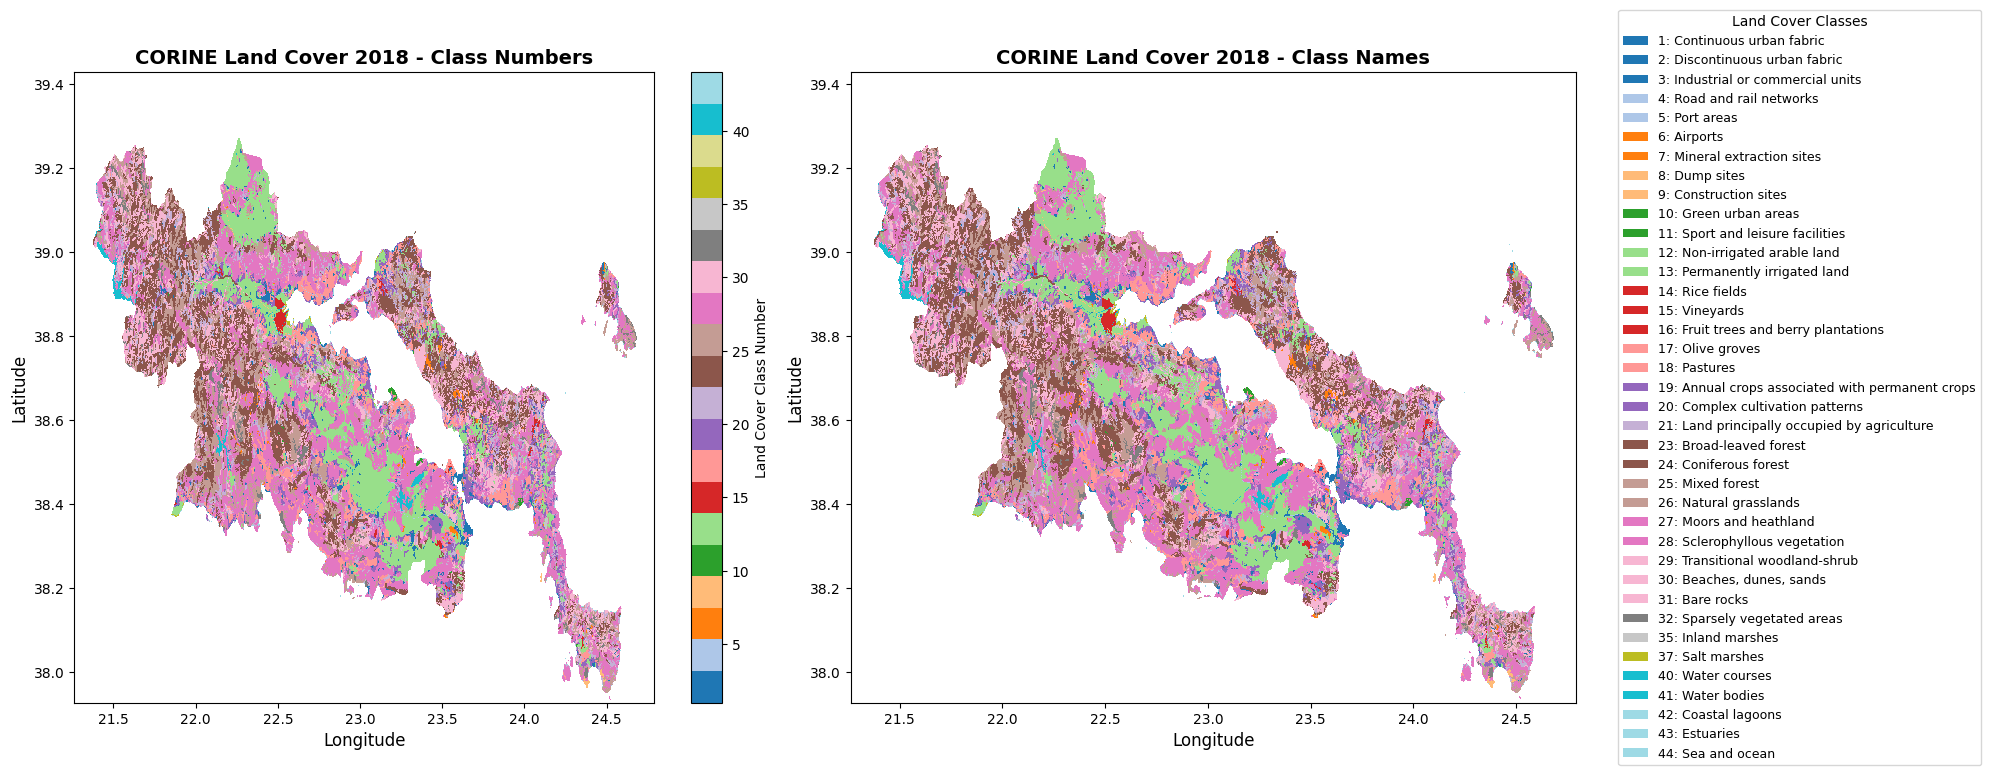

In [54]:
# Select the most recent year (2018)
selected_time = -1  # Last timestep
year = corine_ds.time.dt.year.values[selected_time]
data = corine_ds.isel(time=selected_time)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: With class numbers
im1 = data.plot(
    ax=ax1,
    cmap='tab20',
    add_colorbar=True,
    cbar_kwargs={'label': 'Land Cover Class Number'},
    vmin=1,
    vmax=44
)
ax1.set_title(f'CORINE Land Cover {year} - Class Numbers', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)

# Plot 2: With class names
# Get unique classes present in the data
unique_classes = np.unique(data.values[~np.isnan(data.values)]).astype(int)

im2 = data.plot(
    ax=ax2,
    cmap='tab20',
    add_colorbar=False,
    vmin=1,
    vmax=44
)
ax2.set_title(f'CORINE Land Cover {year} - Class Names', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)

# Add legend with class names (only for classes present in data)
from matplotlib.patches import Patch
legend_elements = []
for cls in sorted(unique_classes):
    if cls in corine_classes:
        # Get color from the colormap
        color = plt.cm.tab20((cls - 1) / 43)
        legend_elements.append(Patch(facecolor=color, label=f'{cls}: {corine_classes[cls]}'))

ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5), 
          fontsize=9, frameon=True, title='Land Cover Classes')

plt.tight_layout()
plt.show()